# B-4064A — AutoML v2 (thermal presets + janelas ajustadas)

Visualiza os resultados da segunda rodada de AutoML, que inclui:
- Presets `thermal` e `thermal_ma`: usam apenas Temperatura Bomba LNA, Vibração Bomba LNA e Temperatura Motor LNA
- `remove_transients` no pré-processamento (remove 2h após restart da bomba)
- Janela de pré-falha de 15 dias (degradação visível a partir de ~Aug 15)
- Período normal definido como > 90 dias antes da falha (antes de Jun/2024)

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists()),
    Path.cwd(),
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
# ==============================
# Configuracao
# ==============================
AUTOML_TASK_ID = '625d8ef75ed746f494563db32e71dd44'
EQUIPMENT_ID = 'B-4064A-novos'

# Eventos
EVENT_DATE_F1 = '2024-08-30 07:58'
EVENT_LABEL_F1 = 'Falha (30/Ago/2024)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)

# Sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2024-04-01'
CALIB_END = '2024-06-01'   # Alinhado ao normal_end_days=90 (antes de Jun/2024)
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Visualizacao
PLOT_MODE = 'separated'         # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [3]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')
    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')
    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_automl_outputs(task_id: str):
    task = Task.get_task(task_id=task_id)

    automl_results = None
    if 'automl_results' in task.artifacts:
        automl_results = task.artifacts['automl_results'].get()

    best_trial_info = None
    if 'best_trial' in task.artifacts:
        best_trial_info = task.artifacts['best_trial'].get()

    if 'best_full_scores' not in task.artifacts:
        raise KeyError('artifact best_full_scores nao encontrado na task AutoML')
    scores = _normalize_scores_df(task.artifacts['best_full_scores'].get())

    threshold = None
    if best_trial_info is not None:
        results = best_trial_info.get('results', {})
        threshold = float(results.get('threshold', 0.0))

    return task, automl_results, best_trial_info, scores, threshold


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw
    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    start_ts = pd.Timestamp(window_start)
    end_ts = pd.Timestamp(window_end)
    dfw = df_base.loc[start_ts:end_ts].copy()
    sw = scores.loc[start_ts:end_ts].copy()
    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')
    return dfw.loc[common_idx], sw.loc[common_idx]


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores: pd.DataFrame, calib_start: str, calib_end: str):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')
    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p),
                'threshold': float(thr),
                'k': int(k),
                'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY),
            })
    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']),
        'k': int(best['k']),
        'n': int(best['n']),
        'percentile': float(best['percentile']),
        'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }

In [4]:
def plot_anomaly_panels(
    df_window, scores_window, threshold_flags, anomaly_flags,
    threshold, threshold_label, n_anomalies,
    event_date, event_label, title,
    output_path=None, dpi=180,
    plot_mode='separated', save_plots=False,
    anomaly_highlight_style='lollipop',
):
    plt.style.use('seaborn-v0_8-whitegrid')
    mode = str(plot_mode).strip().lower()
    highlight_style = str(anomaly_highlight_style).strip().lower()
    saved_paths = []
    sensors = list(df_window.columns)
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix=None):
        if not save_plots or output_path is None:
            return None
        output_path.parent.mkdir(parents=True, exist_ok=True)
        target = output_path.with_name(f"{output_path.stem}_{suffix}{output_path.suffix}") if suffix else output_path
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)
        return target

    def _plot_score_ax(ax_s, x, y):
        ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
        ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(idx_thr, scores_window.loc[idx_thr, 'reconstruction_error'],
                         s=8, color='orange', alpha=0.20, label='Cruzamento bruto', zorder=2)
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            if highlight_style == 'lollipop':
                baseline = float(np.nanmin(y)) if len(y) else 0.0
                ax_s.vlines(idx_pers, ymin=baseline, ymax=y_pers.values,
                            color='red', alpha=0.45, linewidth=1.2, zorder=4, label='Persistencia (lollipop)')
                ax_s.scatter(idx_pers, y_pers, s=44, facecolor='red', edgecolor='white',
                             linewidth=0.9, alpha=0.95, label='Alerta com persistencia', zorder=5)
            else:
                ax_s.scatter(idx_pers, y_pers, s=58, facecolor='red', edgecolor='white',
                             linewidth=1.0, alpha=0.95, label='Alerta com persistencia', zorder=5)
        ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.text(0.99, 0.97, f'Anomalias (persistencia): {int(n_anomalies)}',
                  transform=ax_s.transAxes, ha='right', va='top', fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'))
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4))
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
            fig.suptitle(f'{title} | {col}', fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{slug}')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6))
        _plot_score_ax(ax_s, scores_window.index, scores_window['reconstruction_error'])
        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
    else:
        n_rows = len(sensors) + 1
        fig, axes = plt.subplots(n_rows, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows),
                                  sharex=True, gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]})
        for i, col in enumerate(sensors):
            ax = axes[i]
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
        _plot_score_ax(axes[-1], scores_window.index, scores_window['reconstruction_error'])
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
        fig.tight_layout(rect=[0, 0, 1, 0.99])
        maybe_save(fig)
        plt.show()

    return saved_paths

In [5]:
task, automl_results, best_trial_info, scores, threshold = load_automl_outputs(AUTOML_TASK_ID)

if threshold is None and automl_results is not None and len(automl_results) > 0:
    threshold = float(automl_results.iloc[0]['threshold'])
    print('[AVISO] best_trial nao disponivel — threshold extraido do automl_results.')

df_base, config = load_plot_base(EQUIPMENT_ID)

print(f'Task AutoML: {task.id}')
print(f'Scores: {len(scores)} amostras ({scores.index.min()} → {scores.index.max()})')
print(f'Threshold do melhor trial: {threshold:.6f}')

[AVISO] best_trial nao disponivel — threshold extraido do automl_results.
Task AutoML: 625d8ef75ed746f494563db32e71dd44
Scores: 11983 amostras (2024-01-02 06:00:00 → 2026-03-27 08:00:00)
Threshold do melhor trial: 0.087264


In [6]:
# Top 10 resultados do AutoML
if automl_results is not None:
    top_cols = [
        'composite_score', 'discrimination_ratio',
        'prefailure_alert_rate', 'normal_alert_rate',
        'model', 'preset', 'val_start', 'threshold_percentile',
    ]
    cols = [c for c in top_cols if c in automl_results.columns]
    display(automl_results[cols].head(10).style.format({
        'composite_score': '{:.4f}',
        'discrimination_ratio': '{:.2f}',
        'prefailure_alert_rate': '{:.2%}',
        'normal_alert_rate': '{:.2%}',
        'threshold_percentile': '{:.1f}',
    }).background_gradient(subset=['composite_score'], cmap='Greens'))
else:
    print('artifact automl_results nao disponivel')

,composite_score,discrimination_ratio,prefailure_alert_rate,normal_alert_rate,model,preset,val_start,threshold_percentile
0,0.5847,5.79,65.99%,11.41%,lstm,moving_average,2024-07-01,90.0
1,0.4299,8.39,45.45%,5.42%,lstm,moving_average,2024-07-01,95.0
2,0.4211,4.20,47.47%,11.30%,lstm,baseline,2024-07-01,90.0
3,0.4194,16.02,43.10%,2.69%,lstm,moving_average,2024-07-01,97.5
4,0.4174,4.33,46.80%,10.81%,dense,moving_average,2024-07-01,90.0
5,0.4029,4.21,45.12%,10.71%,dense,baseline,2024-07-01,90.0
6,0.3856,6.70,41.08%,6.13%,lstm,thermal_ma,2024-07-01,95.0
7,0.3840,3.75,43.43%,11.59%,lstm,thermal_ma,2024-07-01,90.0
8,0.3686,6.94,39.06%,5.63%,lstm,baseline,2024-07-01,95.0
9,0.3589,3.42,40.74%,11.91%,lstm,thermal,2024-07-01,90.0


In [7]:
if best_trial_info is not None:
    trial_cfg = best_trial_info.get('trial', {})
    trial_res = best_trial_info.get('results', {})
    print('=== Melhor Trial ===')
    print(f"  Modelo:              {trial_cfg.get('model')}")
    print(f"  Preset:              {trial_cfg.get('preset')}")
    print(f"  Val start:           {trial_cfg.get('val_start')}")
    print(f"  Threshold pct:       {trial_cfg.get('threshold_percentile')}")
    if trial_cfg.get('model') == 'lstm':
        print(f"  seq_len:             {trial_cfg.get('seq_len')}")
        print(f"  lstm_hidden_dim:     {trial_cfg.get('lstm_hidden_dim')}")
        print(f"  lstm_num_layers:     {trial_cfg.get('lstm_num_layers')}")
    elif trial_cfg.get('model') == 'dense':
        print(f"  dense_layers:        {trial_cfg.get('dense_layers')}")
        print(f"  learning_rate:       {trial_cfg.get('learning_rate')}")
    elif trial_cfg.get('model') == 'ocsvm':
        print(f"  nu:                  {trial_cfg.get('ocsvm_nu')}")
        print(f"  gamma:               {trial_cfg.get('ocsvm_gamma')}")
    print()
    print('=== Metricas ===')
    print(f"  composite_score:     {trial_res.get('composite_score', 'N/A'):.4f}")
    print(f"  discrimination_ratio:{trial_res.get('discrimination_ratio', 'N/A'):.2f}")
    print(f"  prefailure_rate:     {trial_res.get('prefailure_alert_rate', 'N/A'):.2%}")
    print(f"  normal_rate:         {trial_res.get('normal_alert_rate', 'N/A'):.2%}")
    print(f"  threshold:           {trial_res.get('threshold', 'N/A'):.6f}")

In [8]:
preset = str(SENSITIVITY_PRESET).strip().lower()
eff_percentiles = list(CALIB_PERCENTILES)
eff_grid = list(CALIB_PERSISTENCE_GRID)
eff_target = float(TARGET_ALERTS_PER_DAY)

if preset == 'conservative':
    eff_percentiles = [99, 99.5, 99.7, 99.9]
    eff_grid = [(3, 5), (4, 6), (5, 8)]
    eff_target = 0.5
elif preset == 'sensitive':
    eff_percentiles = [95, 97, 98, 99]
    eff_grid = [(1, 1), (2, 3), (3, 5)]
    eff_target = 4.0

if AUTO_USE_CALIBRATED_SENSITIVITY:
    CALIB_PERCENTILES = eff_percentiles
    CALIB_PERSISTENCE_GRID = eff_grid
    TARGET_ALERTS_PER_DAY = eff_target
    sens = recommend_sensitivity(scores, CALIB_START, CALIB_END)
    selected_threshold = float(sens['threshold'])
    selected_k = int(sens['k'])
    selected_n = int(sens['n'])
    threshold_label = (
        f"Limite calibrado (thr={selected_threshold:.4f}, "
        f"p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
    )
    print(f'Preset: {preset}')
    print(f'Janela calibracao: {CALIB_START} .. {CALIB_END}')
    print(f'threshold={selected_threshold:.6f}  percentile={sens["percentile"]:.1f}  k={selected_k}  n={selected_n}')
    print(f'Alerts/day estimados: {sens["alerts_per_day"]:.3f}')
else:
    selected_threshold = float(threshold)
    selected_k = 1
    selected_n = 1
    threshold_label = f'Limite do modelo (threshold={selected_threshold:.4f})'
    print('Usando threshold original do modelo.')

Preset: conservative
Janela calibracao: 2024-04-01 .. 2024-06-01
threshold=0.194818  percentile=99.9  k=4  n=6
Alerts/day estimados: 8.254


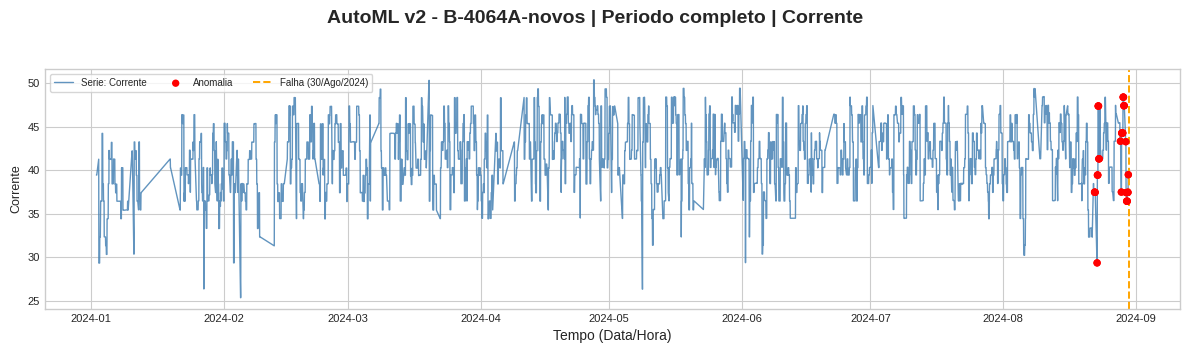

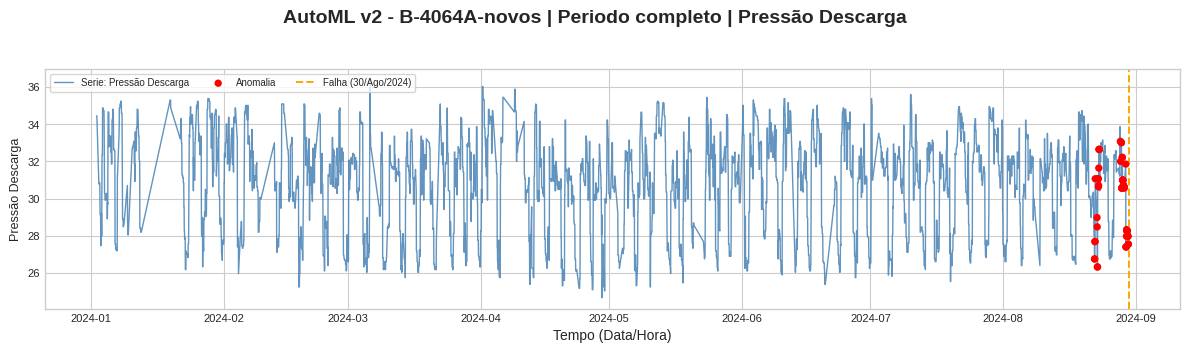

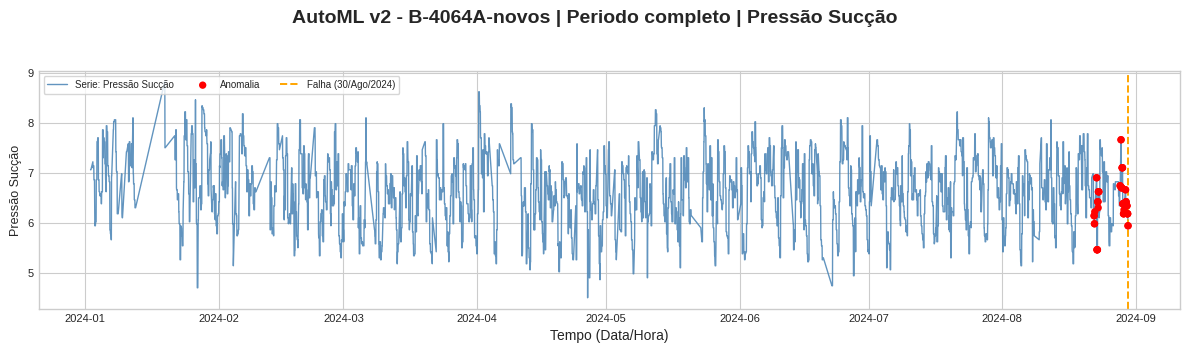

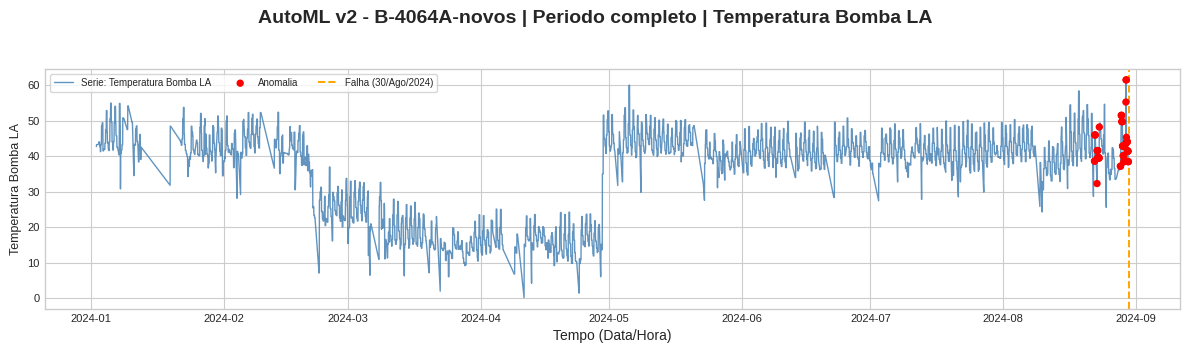

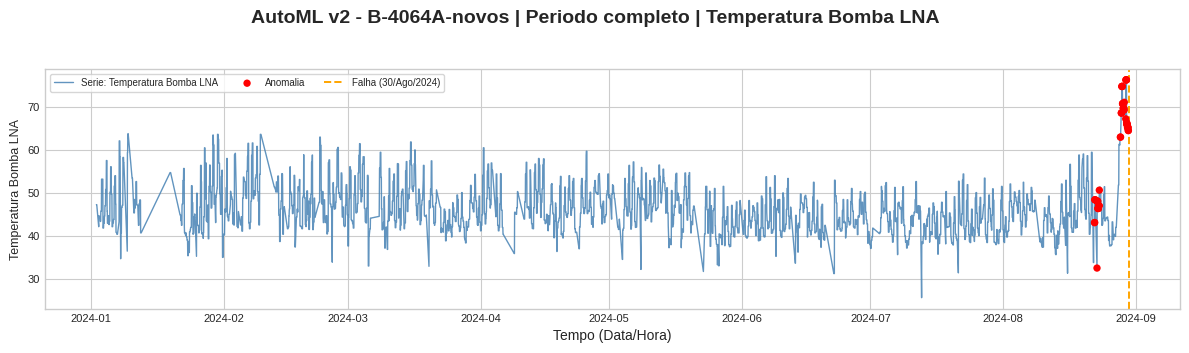

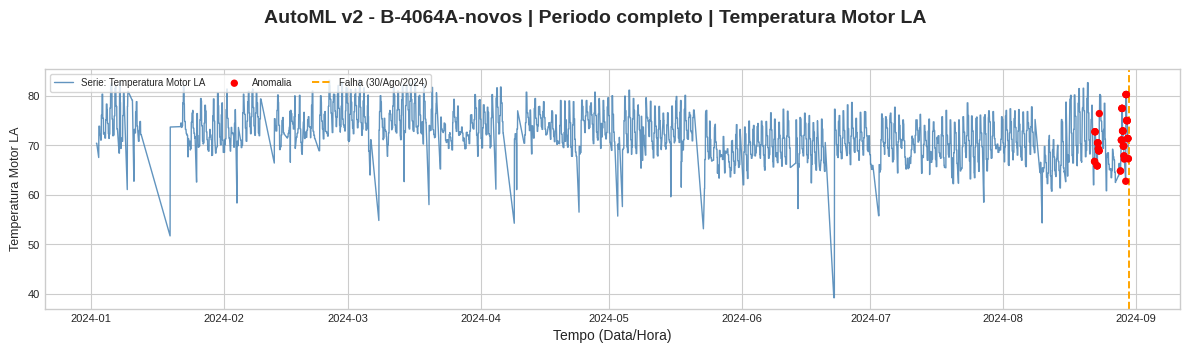

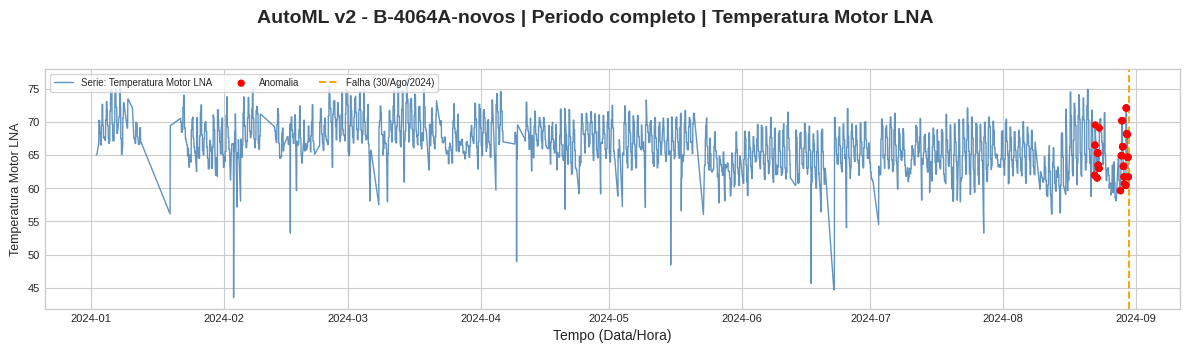

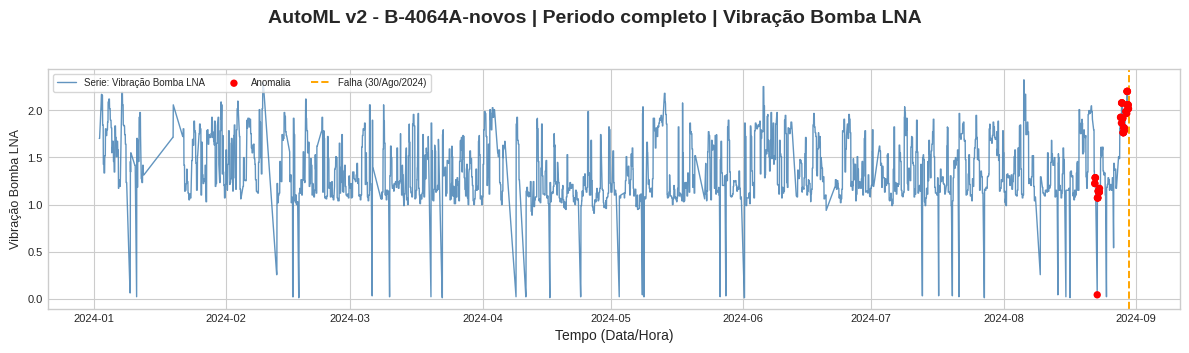

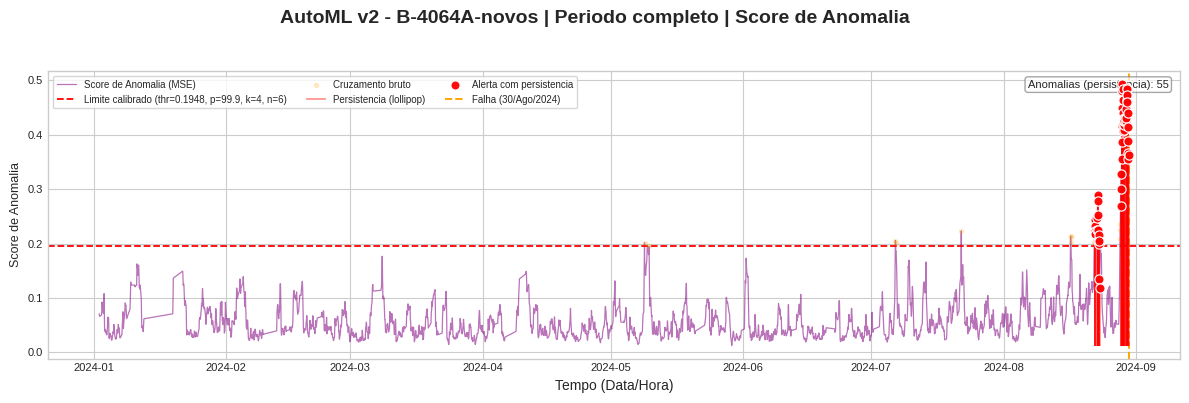

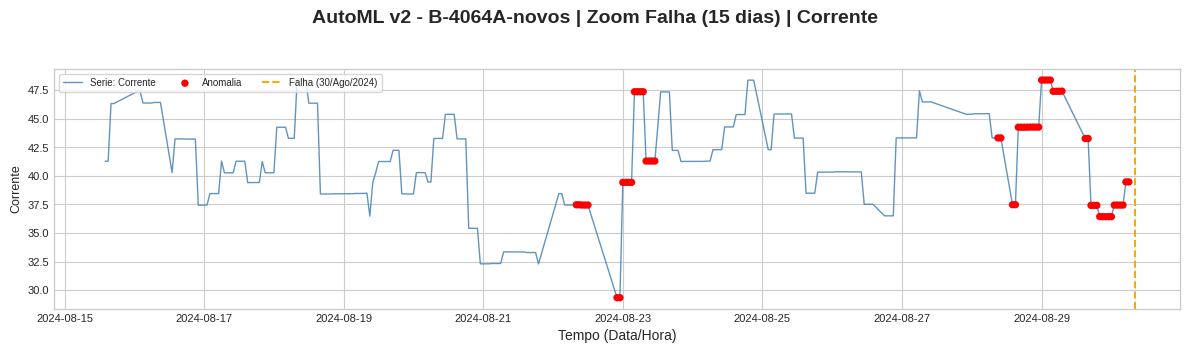

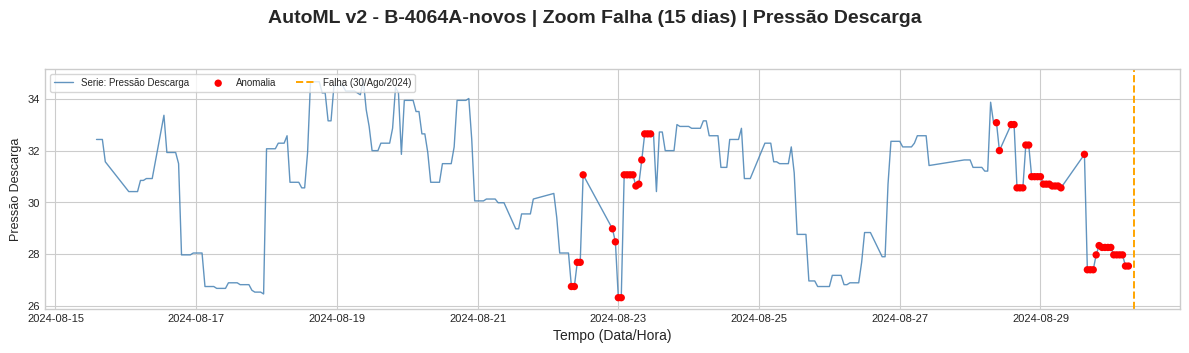

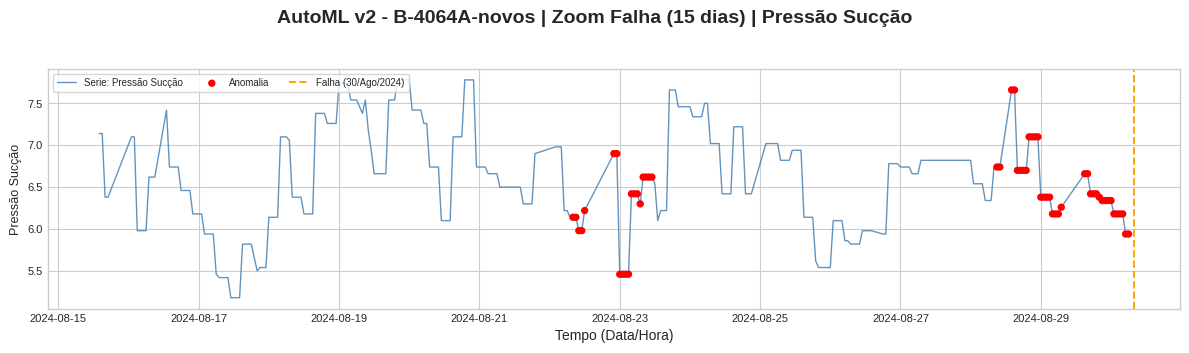

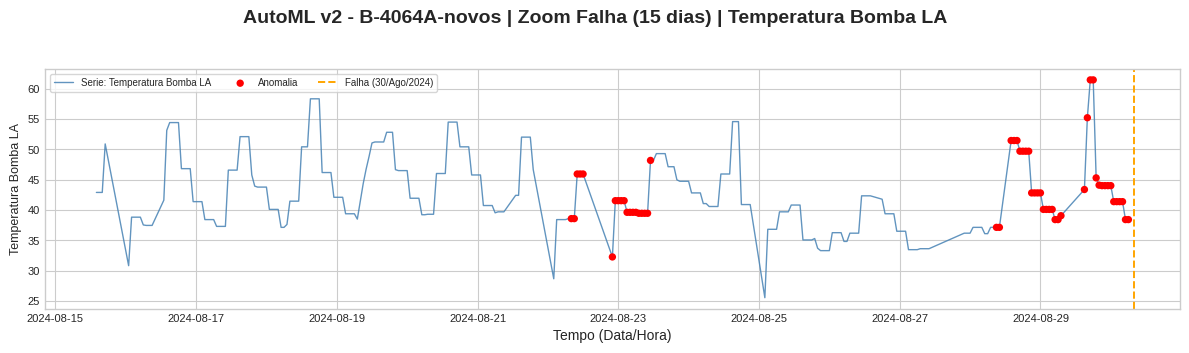

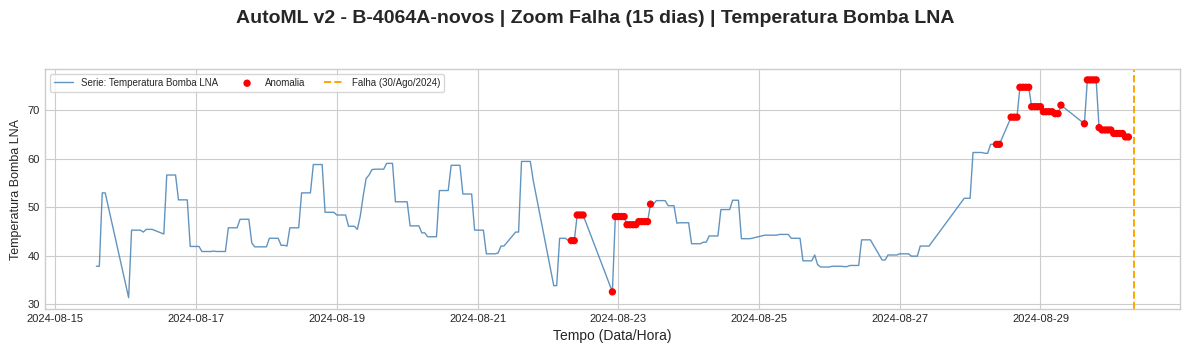

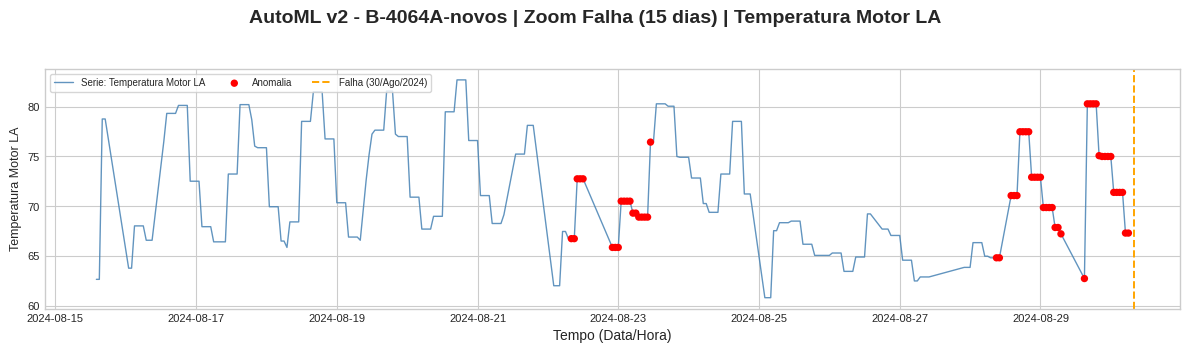

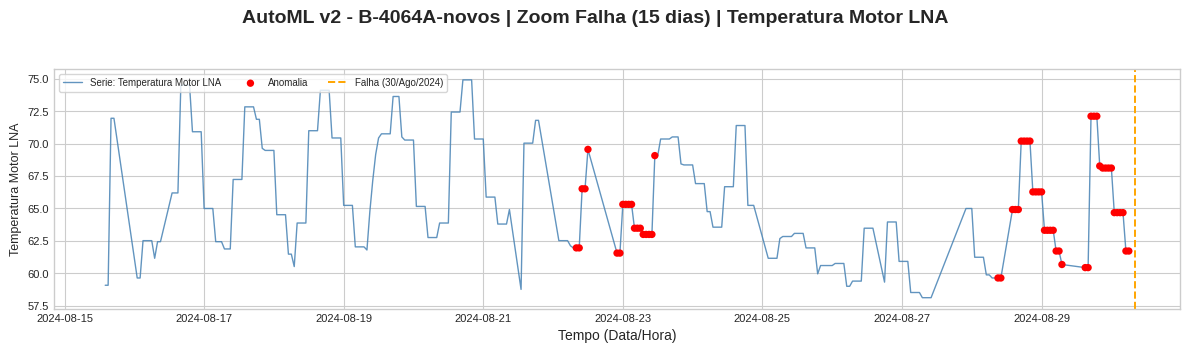

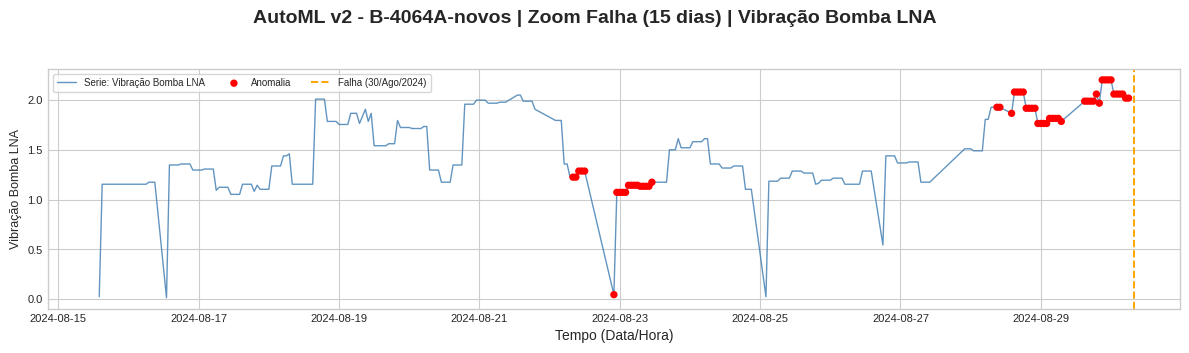

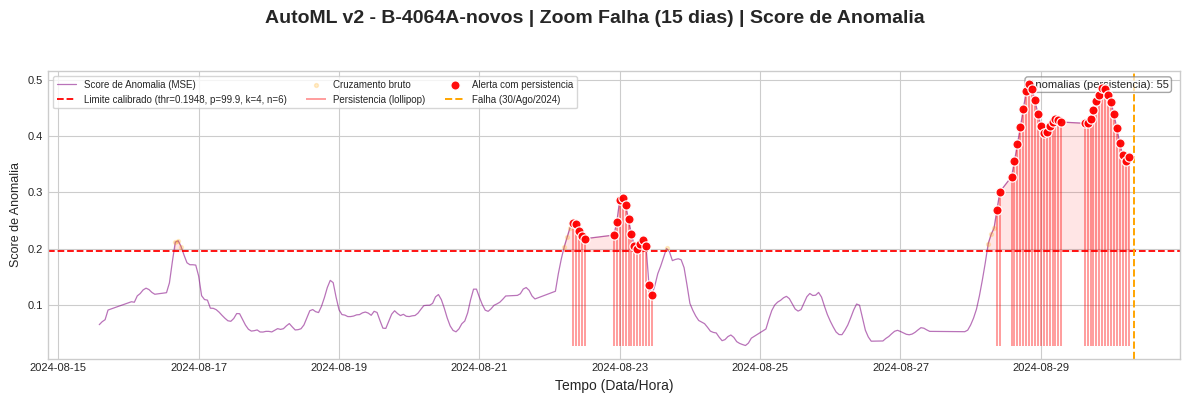

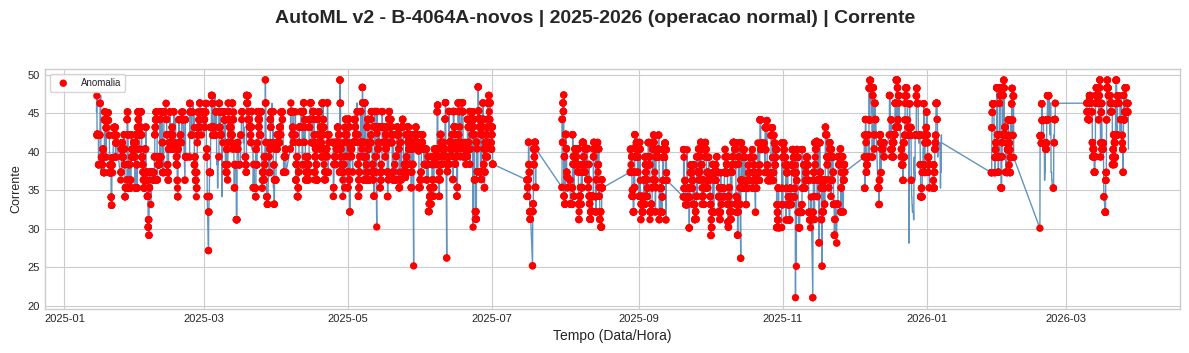

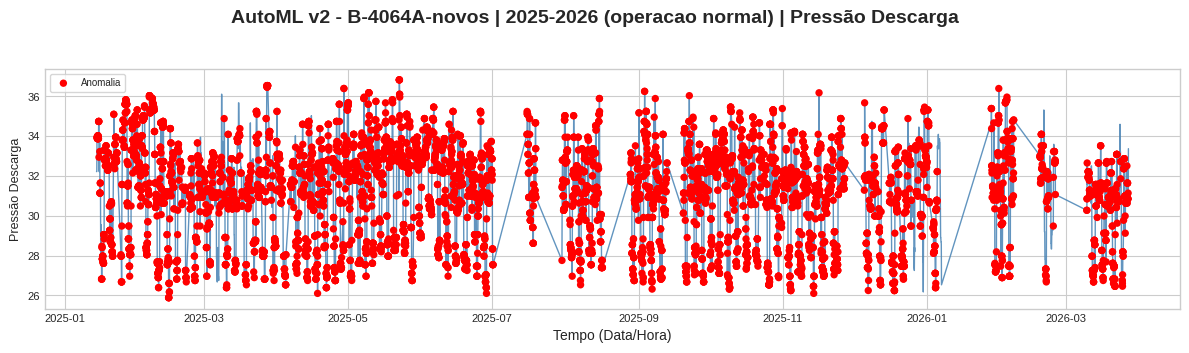

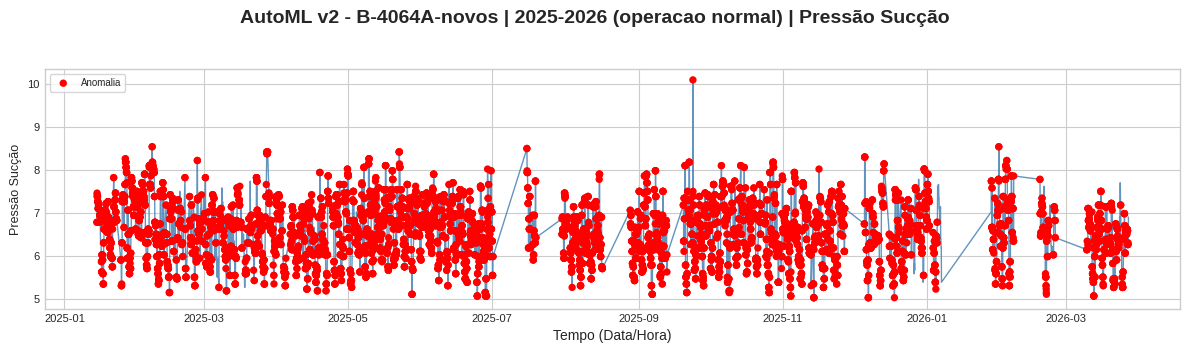

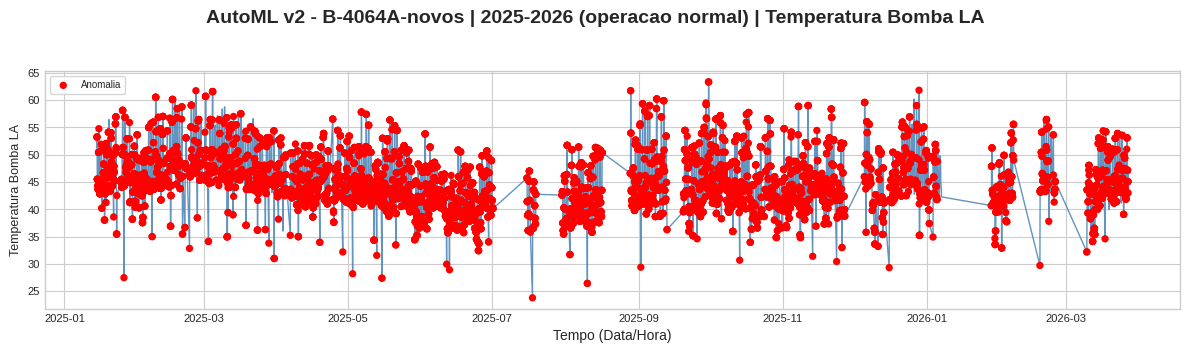

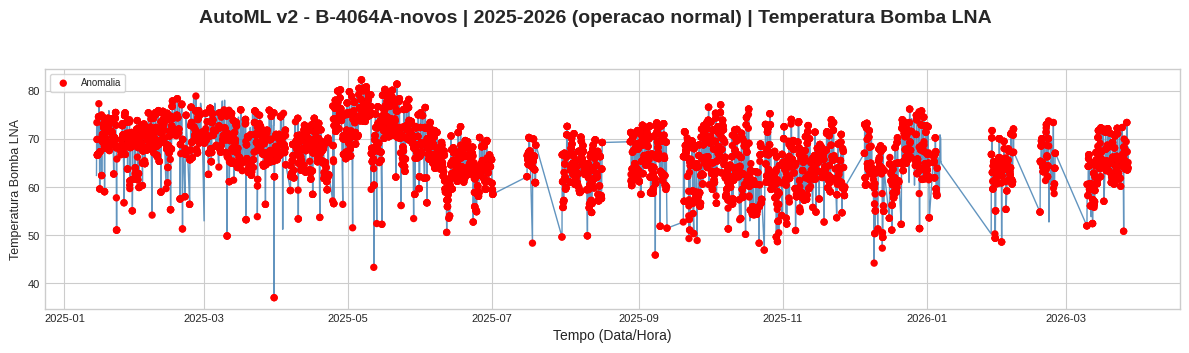

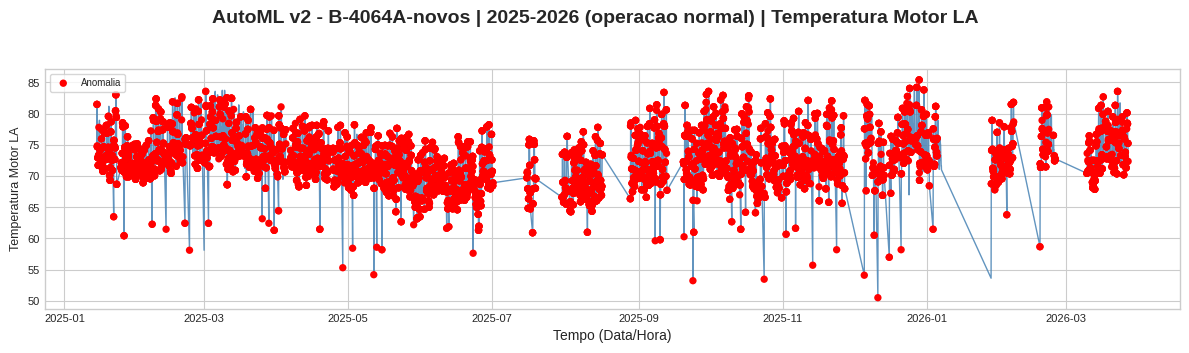

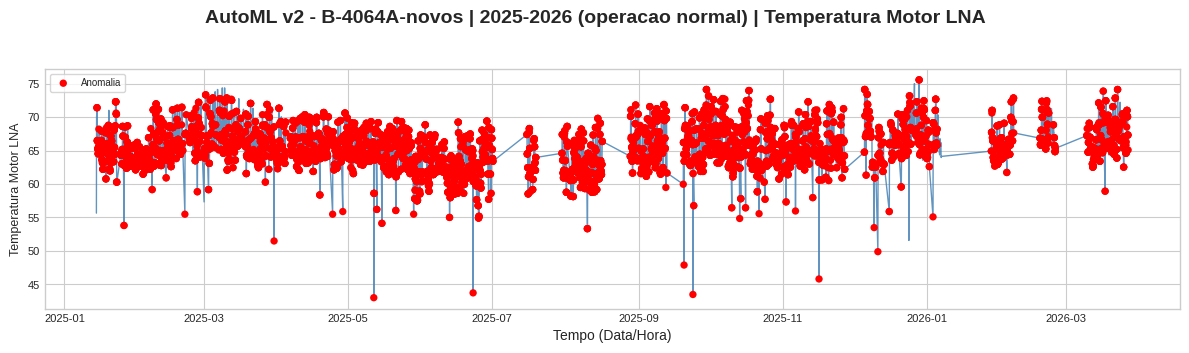

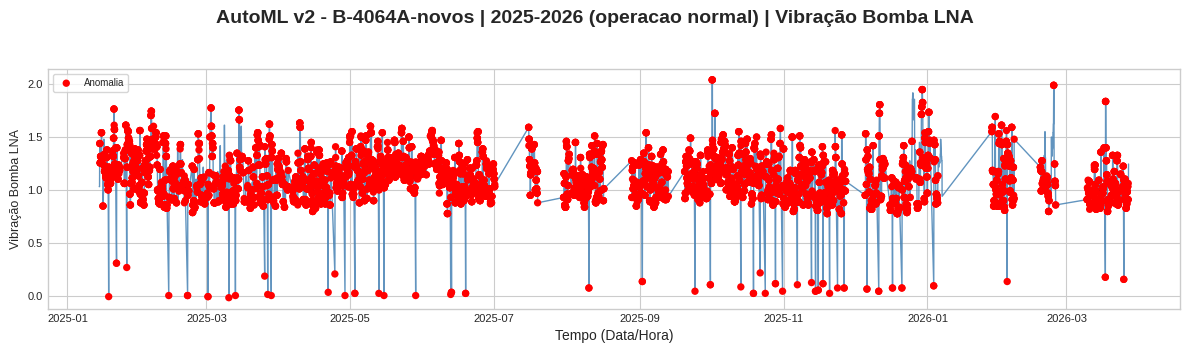

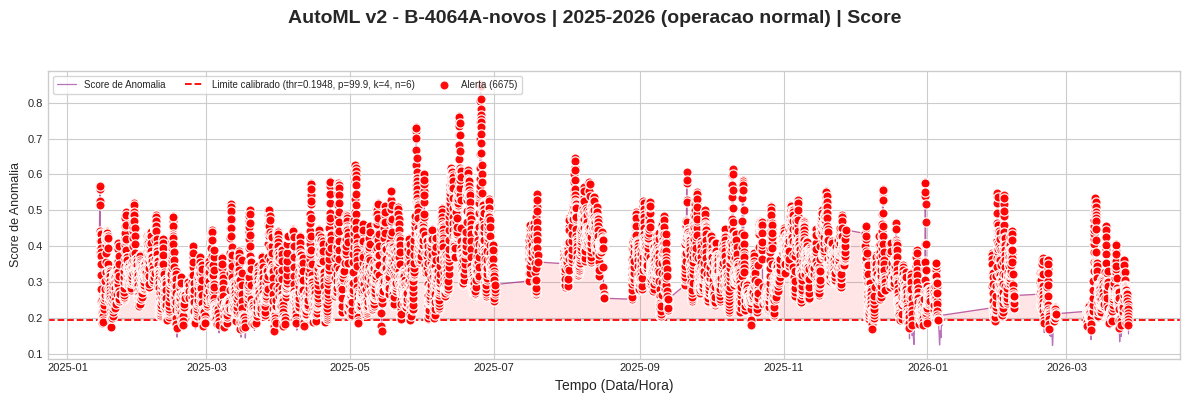


Resumo por janela:


,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Periodo completo ate falha,2024-01-02 06:00:00,2024-08-30 07:58:00,4698,55,1.17,0.194818,4,6
1,Zoom falha (15 dias),2024-08-15 07:58:00,2024-08-30 07:58:00,297,55,18.52,0.194818,4,6
2,Pos-reparo 2025 (sem falha conhecida),2025-01-13 00:00:00,2026-03-27 08:00:00,7285,6675,91.63,0.194818,4,6


In [9]:
windows = [
    {
        'name': 'Periodo completo ate falha',
        'start': scores.index.min(),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML v2 - {EQUIPMENT_ID} | Periodo completo',
        'out': PROJECT_ROOT / 'notebooks' / f'automl_v2_full_{AUTOML_TASK_ID[:8]}.png',
    },
    {
        'name': 'Zoom falha (15 dias)',
        'start': EVENT_TS_F1 - pd.Timedelta(days=15),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML v2 - {EQUIPMENT_ID} | Zoom Falha (15 dias)',
        'out': PROJECT_ROOT / 'notebooks' / f'automl_v2_zoom15_{AUTOML_TASK_ID[:8]}.png',
    },
    {
        'name': 'Pos-reparo 2025 (sem falha conhecida)',
        'start': '2025-01-13',
        'end': scores.index.max(),
        'event_date': None,
        'event_label': None,
        'title': f'AutoML v2 - {EQUIPMENT_ID} | 2025-2026 (operacao normal)',
        'out': PROJECT_ROOT / 'notebooks' / f'automl_v2_2025_{AUTOML_TASK_ID[:8]}.png',
    },
]

summary_rows = []

for w in windows:
    df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
    threshold_flags = scores_window['reconstruction_error'] > selected_threshold
    anomaly_flags = persistence_filter(threshold_flags, k=selected_k, n=selected_n)
    n_anom = int(anomaly_flags.sum())

    event_date = pd.Timestamp(w['event_date']) if w['event_date'] else None
    event_label = w['event_label'] or ''

    if event_date is None:
        # Para janelas sem evento de falha, simplesmente mostra os sensores sem marcacao
        plt.style.use('seaborn-v0_8-whitegrid')
        sensors = list(df_window.columns)
        anomaly_idx = scores_window.index[anomaly_flags]

        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4))
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85)
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, frameon=True)
            fig.suptitle(f"{w['title']} | {col}", fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6))
        ax_s.plot(scores_window.index, scores_window['reconstruction_error'],
                  color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia')
        ax_s.axhline(selected_threshold, color='red', linestyle='--', linewidth=1.3,
                     label=threshold_label)
        ax_s.fill_between(scores_window.index, selected_threshold,
                          scores_window['reconstruction_error'],
                          where=(scores_window['reconstruction_error'] > selected_threshold),
                          color='red', alpha=0.10)
        if n_anom > 0:
            idx_pers = scores_window.index[anomaly_flags]
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            ax_s.scatter(idx_pers, y_pers, s=44, facecolor='red', edgecolor='white',
                         linewidth=0.9, alpha=0.95, label=f'Alerta ({n_anom})', zorder=5)
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
        fig_s.suptitle(f"{w['title']} | Score", fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
    else:
        plot_anomaly_panels(
            df_window=df_window,
            scores_window=scores_window,
            threshold_flags=threshold_flags,
            anomaly_flags=anomaly_flags,
            threshold=selected_threshold,
            threshold_label=threshold_label,
            n_anomalies=n_anom,
            event_date=event_date,
            event_label=event_label,
            title=w['title'],
            output_path=w['out'],
            dpi=OUTPUT_DPI,
            plot_mode=PLOT_MODE,
            save_plots=SAVE_PLOTS,
            anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
        )

    n_samples = len(scores_window)
    summary_rows.append({
        'janela': w['name'],
        'inicio': pd.Timestamp(w['start']),
        'fim': pd.Timestamp(w['end']),
        'n_samples': n_samples,
        'n_anomalies': n_anom,
        'pct_anomalies': round(100.0 * n_anom / n_samples, 2) if n_samples else 0.0,
        'threshold': selected_threshold,
        'k': selected_k,
        'n': selected_n,
    })

print('\nResumo por janela:')
display(pd.DataFrame(summary_rows))